In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

C:\Users\Shubham\AppData\Roaming\Python\Python312\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
(x_train,y_train) , (x_test,y_test) = tf.keras.datasets.mnist.load_data()

In [3]:
x_train = x_train[:5000]
y_train = y_train[:5000]

x_test = x_test[:1000]
y_test = y_test[:1000]

In [4]:
Img_size = 64

In [5]:
def create_detection_data(images):
    X = []
    bboxes = []

    for img in images:
        canvas = np.zeros((Img_size,Img_size),dtype=np.uint8)

        # Random Location
        x = np.random.randint(0,Img_size-28)
        y = np.random.randint(0,Img_size-28)

        canvas[y:y+28,x:x+28] = img

        # normalise bbox
        bbox = [
            x/Img_size,
            y/Img_size,
            (x+28)/Img_size,
            (y+28)/Img_size]
        X.append(canvas)
        bboxes.append(bbox)

    return np.array(X) , np.array(bboxes)
    

In [13]:
X_train , bbox_train = create_detection_data(x_train)
X_test , bbox_test = create_detection_data(x_test)

# convert data from grayscale to RGB
X_train = np.stack([X_train]*3,axis=-1)/255.0
X_test = np.stack([X_test]*3,axis=-1)/255.0

print("Train Shape-->",X_train.shape)

Train Shape--> (5000, 64, 64, 3)


In [14]:
# VGG16 model

base_model = tf.keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(64,64,3))

# freeze 4 layers 
for layer in base_model.layers[:-4]:
    layer.trainable = False
    
 # other layers are trainable
for layer in base_model.layers[-4:]:
    layer.trainable = True

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)

x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)

class_output = tf.keras.layers.Dense(
    10,
    activation='softmax',
    name='class_output'
)(x)

bbox_output = tf.keras.layers.Dense(
    128,
    activation='relu'
)(x)

bbox_output = tf.keras.layers.Dense(
    4,
    activation='sigmoid',
    name='bbox_output'
)(bbox_output)

model = tf.keras.Model(
    inputs = base_model.input,
    outputs = [class_output , bbox_output])

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 64, 64, 3)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1 (Conv2D)         │ (None, 64, 64, 64)        │           1,792 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2 (Conv2D)         │ (None, 64, 64, 64)        │          36,928 │ block1_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_pool (MaxPooling2D)    │ (None, 32, 32, 64)        │               0 │ block1_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_conv1 (Conv2D)         │ (None, 32, 32, 128)       │          73,856 │ block1_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_conv2 (Conv2D)         │ (None, 32, 32, 128)       │         147,584 │ block2_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_pool (MaxPooling2D)    │ (None, 16, 16, 128)       │               0 │ block2_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv1 (Conv2D)         │ (None, 16, 16, 256)       │         295,168 │ block2_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv2 (Conv2D)         │ (None, 16, 16, 256)       │         590,080 │ block3_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv3 (Conv2D)         │ (None, 16, 16, 256)       │         590,080 │ block3_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_pool (MaxPooling2D)    │ (None, 8, 8, 256)         │               0 │ block3_conv3[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv1 (Conv2D)         │ (None, 8, 8, 512)         │       1,180,160 │ block3_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv2 (Conv2D)         │ (None, 8, 8, 512)         │       2,359,808 │ block4_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv3 (Conv2D)         │ (None, 8, 8, 512)         │       2,359,808 │ block4_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_pool (MaxPooling2D)    │ (None, 4, 4, 512)         │               0 │ block4_conv3[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block5_conv1 (Conv2D)         │ (None, 4, 4, 512)         │       2,359,808 │ block4_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block5_conv2 (Conv2D)         │ (None, 4, 4, 512)         │       2,359,808 │ block5_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 14,881,998 (56.77 MB)

 Trainable params: 7,246,734 (27.64 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [15]:
model.compile(
    optimizer = 'adam',
    loss = {
        "class_output" :"sparse_categorical_crossentropy",
        "bbox_output" :"mse"},
    metrics={
        "class_output":"accuracy",
        "bbox_output": "mae" },
)


In [16]:
y_train.shape

(5000,)

In [17]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        patience=2,
        factor=0.5
    )
]

In [18]:
history = model.fit(
    X_train,
    { "class_output":y_train,
     "bbox_output":bbox_train},
    validation_split=0.1,
    epochs=15,
    batch_size=32,
    callbacks=callbacks)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 75s 498ms/step - bbox_output_loss: 0.0368 - bbox_output_mae: 0.1590 - class_output_accuracy: 0.3438 - class_output_loss: 1.6957 - loss: 1.7353 - val_bbox_output_loss: 0.0371 - val_bbox_output_mae: 0.1598 - val_class_output_accuracy: 0.5900 - val_class_output_loss: 1.1182 - val_loss: 1.1582 - learning_rate: 0.0010
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 82s 579ms/step - bbox_output_loss: 0.0313 - bbox_output_mae: 0.1464 - class_output_accuracy: 0.7651 - class_output_loss: 0.6615 - loss: 0.6937 - val_bbox_output_loss: 0.0234 - val_bbox_output_mae: 0.1265 - val_class_output_accuracy: 0.8880 - val_class_output_loss: 0.3795 - val_loss: 0.4080 - learning_rate: 0.0010
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 99s 699ms/step - bbox_output_loss: 0.0235 - bbox_output_mae: 0.1253 - class_output_accuracy: 0.8984 - class_output_loss: 0.3145 - loss: 0.3381 - val_bbox_output_loss: 0.0168 - val_bbox_output_mae: 0.1071 - val_class_output_accuracy: 0.8880 - val_clas

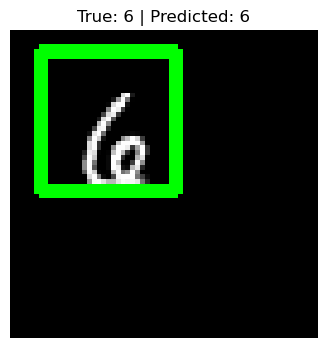

In [29]:
idx = np.random.randint(len(X_test))

image = X_test[idx]
true_label = y_test[idx]

class_pred, bbox_pred = model.predict(
    image[np.newaxis, ...],
    verbose=0
)

pred_label = np.argmax(class_pred[0])

xmin, ymin, xmax, ymax = bbox_pred[0]

# Convert back to pixels
xmin = int(xmin * Img_size)
ymin = int(ymin * Img_size)
xmax = int(xmax * Img_size)
ymax = int(ymax * Img_size)

img = (image * 255).astype(np.uint8)

cv2.rectangle(
    img,
    (xmin, ymin),
    (xmax, ymax),
    (0,255,0),
    2
)

plt.figure(figsize=(6,4))
plt.imshow(img)
plt.title(
    f"True: {true_label} | Predicted: {pred_label}"
)
plt.axis("off")
plt.show()